# Station graph
***

In this notebook I will explore how to create a graph of the station topology. I will find for each station in CAMELS-ES its inmediate downstream station, and then I will create a network (graph) of each river basin.

In [1]:
import pyflwdir
import numpy as np
import pandas as pd
import geopandas as gpd
import rioxarray as rxr
from pathlib import Path
from tqdm.auto import tqdm
import matplotlib.pyplot as plt
import networkx as nx

from camels_es.plots import plot_graph

In [2]:
def find_downstream_neighbor(idx: int, flwdir: pyflwdir.FlwdirRaster, lookup_dict: dict) -> int:
    """
    Finds the station inmediately downstream of the input point.

    Parameters:
    -----------
    idx: int
        Identifier of the input pixel in the flow direction raster (`flwdir`)
    flwdir: pyflwdir.FlwdirRaster
        Flow direction raster
    lookup_dict: dictionary
        Keys are pixel IDs in `flwdir` and values the station IDs

    Returns:
    --------
    int: the ID of the station inmediately downstream
    float: distance to the outlet in meters
    """

    # draw the flowpath
    paths, dists = flwdir.path(idx, unit='m')
    path, dist = paths[0], dists[0]

    # find station in that flowpath
    for pixel in path[1:]:
        if pixel in lookup_dict:
            ID = lookup_dict[pixel]
            return (ID, dist)
    
    return (pd.NA, dist)

In [13]:
from rasterio import features

def vectorize(data, nodata, transform, crs, name="value"):
    feats_gen = features.shapes(
        data,
        mask=data != nodata,
        transform=transform,
        connectivity=8,
    )
    feats = [
        {"geometry": geom, "properties": {name: val}} for geom, val in list(feats_gen)
    ]

    # parse to geopandas for plotting / writing to file
    gdf = gpd.GeoDataFrame.from_features(feats, crs=crs)
    gdf[name] = gdf[name].astype(data.dtype)
    return gdf

## Config

In [5]:
# configure paths
path_merit = Path('/home/casadoj/Data/MERIT/ES')
path_camels = Path('/home/casadoj/Data/CAMELS-ES')

## Data

### Digital Elevation Model

In [6]:
# load flow direction map and convert it to `flwdir`
flwdir = rxr.open_rasterio(path_merit / 'dir.tif').squeeze(dim='band')
crs = flwdir.rio.crs
flwdir = pyflwdir.from_array(
    flwdir.data,
    ftype='d8',
    transform=flwdir.rio.transform(),
    check_ftype=False,
    latlon=True
)

# Compute upstream area map in km²
upstream_area = flwdir.upstream_area(unit='km2')
mask_area = upstream_area > 20

# Map of the Strahler order
strahler = flwdir.stream_order(type='strahler', mask=mask_area)

### Stations

In [ ]:
# load stations geolocated in the MERIT DEM
stations = gpd.read_file(
    path_camels / 'preprocessing' / 'lfcoords' / 'old' / 'stations_camelses_3sec.shp',
    columns=['ID', 'geometry', 'area_3sec']
).set_index('ID')
stations.rename(columns={'area_3sec': 'area_skm'}, inplace=True)
stations['kind'] = 'station'
if stations.crs != crs:
    points.to_crs(crs)
stations.drop_duplicates(subset='geometry', inplace=True)
print(f'{len(stations)} stations')



835 stations


## Processing

### Cathment Delineation

#### Station Subbasins

835 subbasins


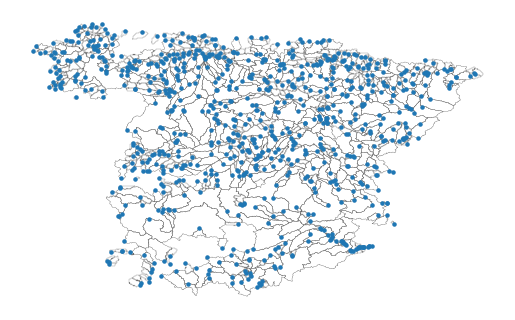

In [ ]:
# get station indices in the flow direction object
stations['pixel'] = flwdir.index(
    xs=stations.geometry.x,
    ys=stations.geometry.y
)

# delineate the station subbasins
subbasins_map = flwdir.basins(idxs=stations.pixel)

# convert to GeoDataFrame
subbasins = vectorize(
    data=subbasins_map.astype(np.int32), 
    nodata=0, 
    transform=flwdir.transform, 
    crs=crs, 
    name="subbasin"
)

# Assig station ID
subbasin_to_station = pd.Series(stations.index, index=subbasins_map.ravel()[stations.pixel]).to_dict()
subbasins['ID'] = subbasins['subbasin'].map(subbasin_to_station)
subbasins.set_index('ID', drop=True, inplace=True)
subbasins['area_skm'] = upstream_area.ravel()[stations.loc[subbasins.index, 'pixel']].round(0).astype(int)
print(f'{len(subbasins)} subbasins')

# export
subbasins.to_file('subbasins_stations.geojson', driver='GeoJSON')

# plot stations and subbasins
fig, ax = plt.subplots()
stations.plot(ax=ax, markersize=5, label='station')
subbasins.boundary.plot(ax=ax, edgecolor='dimgrey', lw=.2, zorder=0)
ax.set_aspect('equal')
ax.axis('off');

#### Outlets & River Basins

no. outlets: 61
61 basins


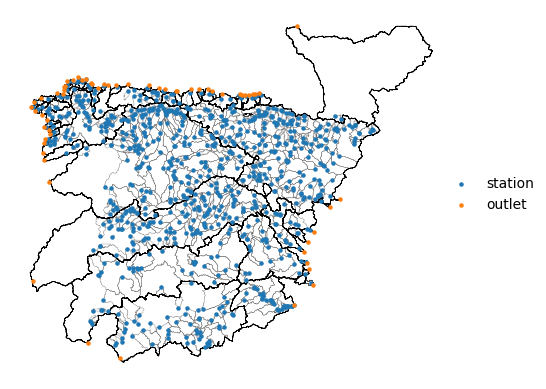

In [43]:
# compute all flowpaths from the stations
paths, dists = flwdir.path(stations.pixel, unit='m')

# find unique river outlets
outlets_idx = list(set(path[-1] for path in paths))
print(f'no. outlets: {len(outlets_idx)}')

# Delineate the outlet basins and convert to GeoDataFrame
basin_map = flwdir.basins(idxs=outlets_idx)
basins = vectorize(
    data=basin_map.astype(np.int32), 
    nodata=0, 
    transform=flwdir.transform, 
    crs=crs,
    name="ID"
)
basins.set_index('ID', drop=True, inplace=True)
basins.sort_index(axis=0, inplace=True)
print(f'{len(basins)} basins')

# Create GeoDataFrame of outlets
outlets = gpd.GeoDataFrame(
    data={
        'ID': basin_map.ravel()[outlets_idx],
        'pixel': outlets_idx, 
        'kind': 'outlet'
        },
    geometry=gpd.points_from_xy(*flwdir.xy(outlets_idx)),
    crs=crs
).set_index('ID')
outlets.sort_index(axis=0, inplace=True)
outlets['area_skm'] = upstream_area.ravel()[outlets.pixel].round(0).astype(int)
# sort outlets counter-clockwisely starting from the North
center_x, center_y = -3.7, 40.0
outlets['angle'] = np.arctan2(
    outlets.geometry.y - center_y, 
    outlets.geometry.x - center_x
    )
outlets['angle'] = (outlets['angle'] - np.radians(60)) % (2 * np.pi) # start in the French Cantabrian border
outlets.sort_values('angle', inplace=True)

# Plot outlets and river basins
fig, ax = plt.subplots()
stations.plot(ax=ax, markersize=5, label='station', zorder=2)
outlets.plot(ax=ax, markersize=5, label='outlet', zorder=3)
subbasins.boundary.plot(ax=ax, edgecolor='dimgrey', lw=.2, zorder=0)
basins.boundary.plot(ax=ax, edgecolor='k', lw=.5, zorder=1)
fig.legend(frameon=False, loc=5)
ax.axis('off');

Get each outlet to be named after the basin codes:
* Duero: 2xxx
* Tajo: 3xxx
* Guadiana: 4xxx
* Guadalquivir: 5xxx
...

In [44]:
# Cross stations and basins
station_basin = stations.sjoin(basins, how="inner", predicate="intersects")
station_basin.index.name = 'station'
station_basin.rename(columns={'ID_right': 'basin'}, inplace=True)

# Find new IDs for outlets
mapping = {}
for ID_new in tqdm(range(1000, 9999, 1000)):
    mask = (station_basin.index >= ID_new) & (station_basin.index < ID_new + 1000)
    ID_basin = station_basin[mask].basin.unique()
    if len(ID_basin) == 0:
        continue
    elif len(ID_basin) == 1:
        ID_old = ID_basin.item()
        while (ID_new in stations.index) | (ID_new in mapping.values()):
            ID_new +=1       
        mapping[ID_old] = ID_new
    else:
        for ID_old in outlets.loc[ID_basin].sort_values('angle').index:
            while (ID_new in stations.index) | (ID_new in mapping.values()):
                ID_new += 1
            mapping[ID_old] = ID_new
        continue

# Assing new IDs to outlets and basins
outlets.index = outlets.index.map(mapping)
basins.index = basins.index.map(mapping)
basins.sort_index(inplace=True)
basins['area_skm'] = outlets.loc[basins.index, 'area_skm'].astype(int)

# Export
outlets.drop(['angle'], axis=1).to_file('outlets.geojson', driver='GeoJSON')
basins.to_file('basins.geojson', driver='GeoJSON')

  0%|          | 0/9 [00:00<?, ?it/s]

#### `subbasins_streamorder`

It delineates subbasins for a five Strahler order, and it also provides the outlet pixel.

In [246]:
# # Delineate subbasins
# subbasin_map, idxs_out = flwdir.subbasins_streamorder(min_sto=2)#, min_sto=7)

# # GeoDataFrame of subbasins
# subbasins = vectorize(subbasin_map.astype(np.int32), 0, flwdir.transform, name="subbasin")
# subbasins.set_index('subbasin', drop=True, inplace=True)
# print(f'{len(subbasins)} subbasins')

# # GeoDataFrame of points
# confluences = gpd.GeoDataFrame(
#     data={'subbasin': subbasin_map.ravel()[idxs_out]}, 
#     geometry=gpd.points_from_xy(*flwdir.xy(idxs_out), crs=crs)
# ).set_index('subbasin')
# print(f'{len(confluences)} confluences')

# # keep only those within the basins
# subbasins = subbasins.sjoin(basins, how="inner", predicate="within")
# print(f'{len(subbasins)} subbasins')
# confluences = confluences.loc[confluences.index.intersection(subbasins.index)]
# print(f'{len(confluences)} confluences')

# # # Export
# # subbasins.to_file('subbasins.shp')
# # confluences.to_file('confluences.shp')

In [247]:
# fig, ax = plt.subplots()

# basins.boundary.plot(ax=ax, edgecolor='red', lw=.5)
# subbasins.plot(ax=ax, edgecolor='k', lw=.2, alpha=.25)
# confluences.plot(markersize=3, c='k', ax=ax)
# ax.set_aspect('equal')
# ax.axis('off');

#### `streams`

In [248]:
# # Delineate streams
# streams = gpd.GeoDataFrame.from_features(
#     flwdir.streams(mask=mask_area),
#     crs=crs
# )

# # # export
# # streams.to_file('streams.geojson', driver='GeoJSON')

### Find Downstream Points

In [45]:
# merge stations and outlets
points = pd.concat([stations, outlets], axis=0)
points['lat'] = points.geometry.y
points['lon'] = points.geometry.x
points.rename(columns={'area_skm': 'area', 'flwdir_index': 'pixel'}, inplace=True, errors='ignore')
points['strahler'] = strahler.ravel()[points.pixel]

# find points downstream
pixel_to_id = dict(zip(points['pixel'], points.index))
points[['downstream_ID', 'dist_to_outlet']] = [find_downstream_neighbor(pixel, flwdir, pixel_to_id) for pixel in points['pixel']]

# compute distance to downstream station
dist_m = pd.Series(index=points.index, name='dist_m')
for ID in tqdm(dist_m.index):
    ds_ID = points.loc[ID, 'downstream_ID']
    if pd.isnull(ds_ID):
        dist_m[ID] = points.loc[ID, 'dist_to_outlet']
    else:
        dist_m[ID] = np.diff(points.loc[[ds_ID, ID], 'dist_to_outlet'])[0]
points['dist_m'] = dist_m

  0%|          | 0/896 [00:00<?, ?it/s]

#### Confluences

In [ ]:
# for ID in outlets.index:
#     print(ID)
#     parents = points[points.downstream_ID == ID]
#     if len(parents) < 2:
#         continue
#     else:
#         break

0
1


In [ ]:
# paths, dists = flwdir.path(parents['pixel'])
# n_parents = len(parents)
# confluences = []
# for i in range(n_parents):
#     for j in range(i + 1, n_parents):
#         print(i, '-', j)
#         for pixel in paths[i]:
#             if pixel in paths[j]:
#                 confluences.append(pixel.item())
#                 break
# confluences = list(set(confluences))

In [ ]:
# for ID2 in parents.index:
#     parents2 = points[points.downstream_ID == ID2]
#     if len(parents2) < 2:
#         continue
#     else:
#         print(ID2)
#         break

## Graph

In [46]:
# Initialize a Directed Graph
G = nx.DiGraph()

# Add nodes
node_attrs = points[['kind', 'lat', 'lon', 'area', 'pixel', 'strahler']].to_dict('index')
for node_id, attrs in node_attrs.items():
    G.add_node(node_id, **attrs)
    
# Add edges
edges = points.dropna(subset=['downstream_ID'])
for ID, row in edges.iterrows():
    G.add_edge(u_of_edge=ID, v_of_edge=row['downstream_ID'], dist_m=row['dist_m'])

print(f"Graph created with {G.number_of_nodes()} stations and {G.number_of_edges()} connections.")

Graph created with 896 stations and 835 connections.


In [47]:
# target_node = 9027

# upstream_stations = list(nx.ancestors(G, target_node))
# print('ancestors:', upstream_stations)
# source_node = upstream_stations[-1]

# if G.has_node(source_node) and G.has_node(target_node):
#     if nx.has_path(G, source_node, target_node):
#         dist = nx.shortest_path_length(G, source_node, target_node, weight='dist_m')
#         print(f"Distance {source_node}-{target_node}: {dist/1000:.2f} km")
#     else:
#         print("Nodes exist, but they are in different river basins!")
# else:
#     print("One of the station IDs is missing from the graph.")

In [48]:
outlets = [node for node, degree in G.out_degree() if degree == 0]
print(f'{len(outlets)} outlet stations.')

headwaters = [node for node, degree in G.in_degree() if degree == 0]
print(f'{len(headwaters)} headwater stations.')

61 outlet stations.
412 headwater stations.


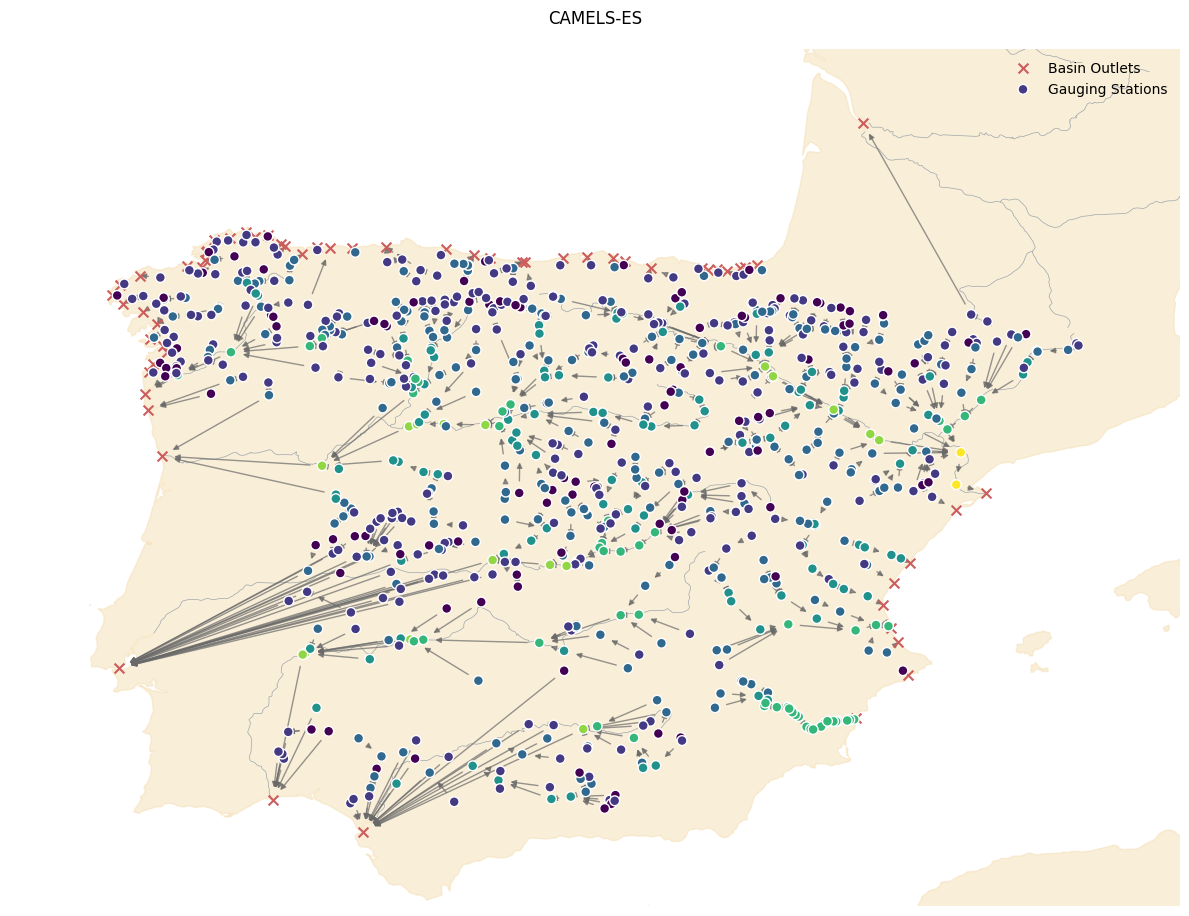

In [49]:
plot_graph(
    graph=G, 
    nodes=G.nodes, 
    title='CAMELS-ES', 
    labels=False, 
    figsize=(12, 10)
)